In [1]:
# Install required libraries 
!pip install pandas matplotlib scikit-learn seaborn joblib

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
loans = pd.read_csv('bank_loans_full_schema.csv')

# Display the first few rows
loans.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [3]:
# Check data types and shape
print("Shape:", loans.shape)
print("\nData Types:\n")
print(loans.dtypes)

Shape: (10000, 55)

Data Types:

emp_title                               str
emp_length                          float64
state                                   str
homeownership                           str
annual_income                       float64
verified_income                         str
debt_to_income                      float64
annual_income_joint                 float64
verification_income_joint               str
debt_to_income_joint                float64
delinq_2y                             int64
months_since_last_delinq            float64
earliest_credit_line                  int64
inquiries_last_12m                    int64
total_credit_lines                    int64
open_credit_lines                     int64
total_credit_limit                    int64
total_credit_utilized                 int64
num_collections_last_12m              int64
num_historical_failed_to_pay          int64
months_since_90d_late               float64
current_accounts_delinq               int64

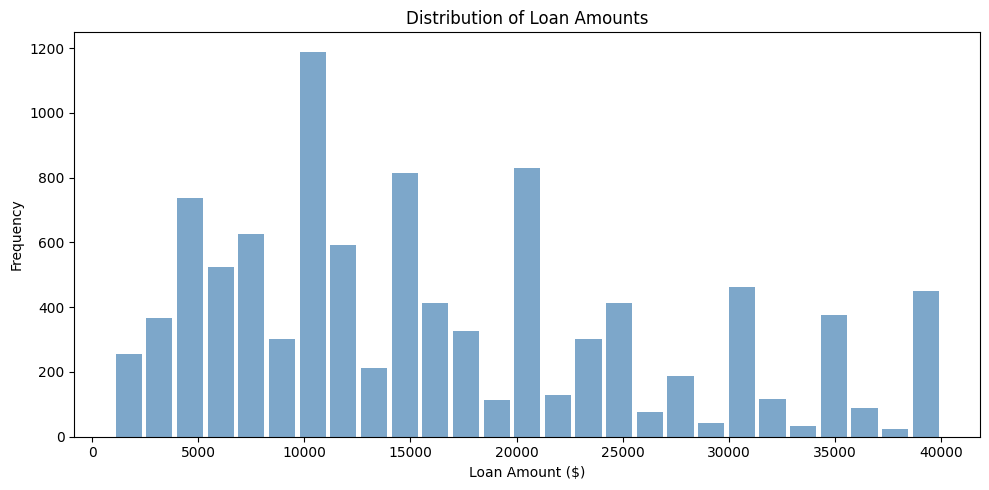

In [4]:
# Histogram of loan amounts
plt.figure(figsize=(10, 5))
plt.hist(x=loans['loan_amount'], bins='auto', color='steelblue', alpha=0.7, rwidth=0.85)
plt.xlabel("Loan Amount ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Loan Amounts")
plt.tight_layout()
plt.show()


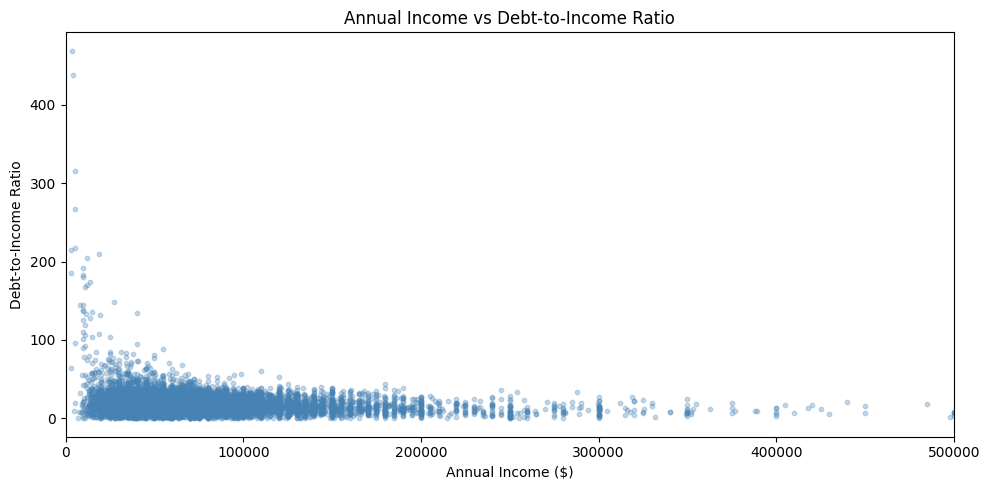

In [5]:
# Scatter plot: annual income vs debt-to-income ratio
plt.figure(figsize=(10, 5))
plt.scatter(loans['annual_income'], loans['debt_to_income'], 
            c='steelblue', alpha=0.3, s=10)
plt.xlabel('Annual Income ($)')
plt.ylabel('Debt-to-Income Ratio')
plt.title('Annual Income vs Debt-to-Income Ratio')
plt.xlim(0, 500000)  # cap for readability
plt.tight_layout()
plt.show()

loan_status
Current               9375
Fully Paid             447
In Grace Period         67
Late (31-120 days)      66
Late (16-30 days)       38
Charged Off              7
Name: count, dtype: int64


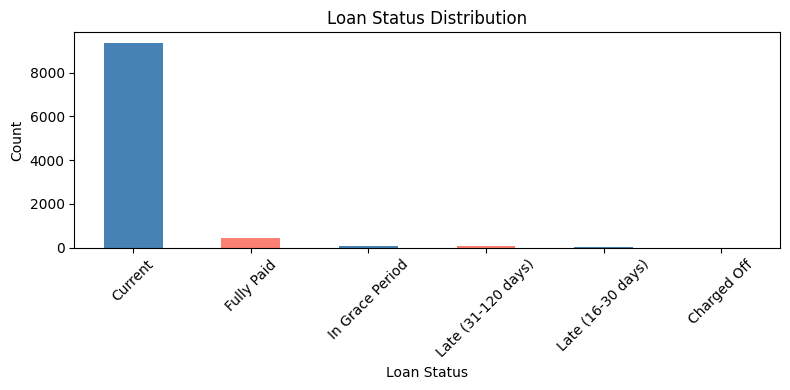

In [6]:
# Loan status value counts and bar chart
print(loans['loan_status'].value_counts())

plt.figure(figsize=(8, 4))
loans['loan_status'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

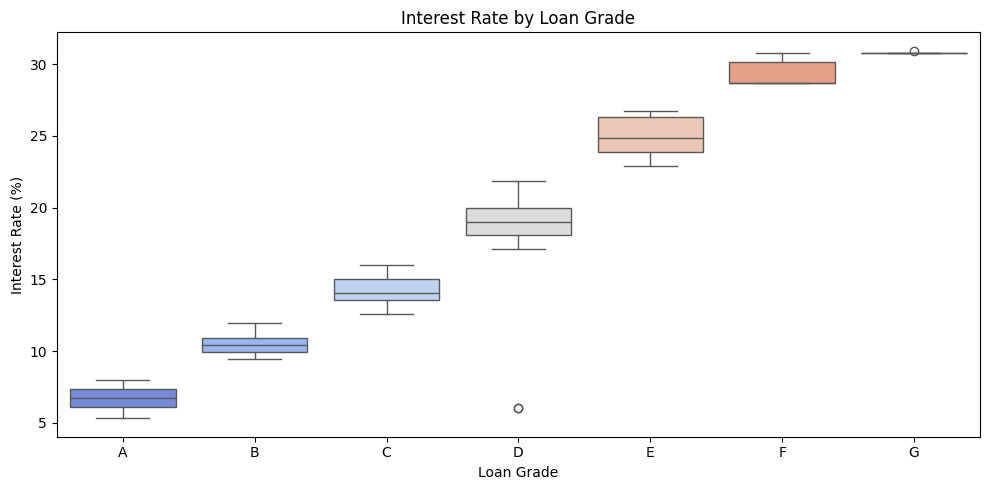

In [7]:
# Box plot: interest rate by loan grade
plt.figure(figsize=(10, 5))
sns.boxplot(x='grade', y='interest_rate', data=loans, order=['A','B','C','D','E','F','G'],
            palette='coolwarm')
plt.title('Interest Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Interest Rate (%)')
plt.tight_layout()
plt.show()

In [8]:
# Create binary target: 1 = Charged Off (default), 0 = Fully Paid / Current
print("Unique loan statuses:", loans['loan_status'].unique())

# Map to binary
status_map = {
    'Fully Paid': 0,
    'Current': 0,
    'Charged Off': 1,
    'Late (31-120 days)': 1,
    'Late (16-30 days)': 1,
    'In Grace Period': 1,
    'Default': 1
}

loans['default'] = loans['loan_status'].map(status_map)
print("\nDefault value counts:\n", loans['default'].value_counts())

Unique loan statuses: <StringArray>
[           'Current',         'Fully Paid',    'In Grace Period',
 'Late (31-120 days)',        'Charged Off',  'Late (16-30 days)']
Length: 6, dtype: str

Default value counts:
 default
0    9822
1     178
Name: count, dtype: int64


In [9]:
# Check missing values
print("Missing values per column:\n")
print(loans.isnull().sum()[loans.isnull().sum() > 0])

Missing values per column:

emp_title                            833
emp_length                           817
debt_to_income                        24
annual_income_joint                 8505
verification_income_joint           8545
debt_to_income_joint                8505
months_since_last_delinq            5658
months_since_90d_late               7715
months_since_last_credit_inquiry    1271
num_accounts_120d_past_due           318
dtype: int64


In [10]:
# Fill numerical columns with mean
num_fill_cols = ['interest_rate', 'debt_to_income', 'months_since_last_delinq',
                 'months_since_90d_late', 'months_since_last_credit_inquiry',
                 'num_accounts_120d_past_due', 'debt_to_income_joint',
                 'annual_income_joint']

for col in num_fill_cols:
    if col in loans.columns:
        loans[col].fillna(loans[col].mean(), inplace=True)

# Drop rows where emp_length is missing (employment info is critical)
loans.dropna(subset=['emp_length'], inplace=True)

# Drop rows where target is missing
loans.dropna(subset=['default'], inplace=True)

# Confirm no remaining critical nulls
print("Remaining missing values:\n")
print(loans.isnull().sum()[loans.isnull().sum() > 0])

Remaining missing values:

emp_title                             16
debt_to_income                         1
annual_income_joint                 7890
verification_income_joint           7924
debt_to_income_joint                7890
months_since_last_delinq            5193
months_since_90d_late               7105
months_since_last_credit_inquiry    1123
num_accounts_120d_past_due           296
dtype: int64


In [11]:
# Select relevant numerical and categorical features
feature_cols = [
    'annual_income', 'debt_to_income', 'inquiries_last_12m',
    'total_credit_lines', 'open_credit_lines', 'total_credit_limit',
    'total_credit_utilized', 'num_collections_last_12m',
    'num_historical_failed_to_pay', 'current_accounts_delinq',
    'accounts_opened_24m', 'num_satisfactory_accounts',
    'num_active_debit_accounts', 'total_debit_limit',
    'num_total_cc_accounts', 'num_open_cc_accounts',
    'num_cc_carrying_balance', 'num_mort_accounts',
    'account_never_delinq_percent', 'tax_liens',
    'public_record_bankrupt', 'loan_amount', 'interest_rate',
    'installment', 'balance', 'paid_total',
    # Categorical
    'homeownership', 'verified_income', 'loan_purpose',
    'application_type', 'grade'
]

loans_model = loans[feature_cols + ['default']].copy()
loans_model.dropna(inplace=True)

print("Modeling dataset shape:", loans_model.shape)

Modeling dataset shape: (9182, 32)


In [12]:
# Encode homeownership
homeownership_map = {'RENT': 0, 'MORTGAGE': 1, 'OWN': 2, 'OTHER': 3}
loans_model['homeownership'] = loans_model['homeownership'].map(homeownership_map)

# Encode verified_income
verified_map = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
loans_model['verified_income'] = loans_model['verified_income'].map(verified_map)

# Encode loan_purpose
purpose_vals = loans_model['loan_purpose'].unique()
purpose_map = {v: i for i, v in enumerate(sorted(purpose_vals))}
print("Loan purpose mapping:", purpose_map)
loans_model['loan_purpose'] = loans_model['loan_purpose'].map(purpose_map)

# Encode application_type
app_map = {'individual': 0, 'joint': 1}
loans_model['application_type'] = loans_model['application_type'].str.lower().map(app_map)

# Encode grade
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
loans_model['grade'] = loans_model['grade'].map(grade_map)

print("\nSample encoded data:")
loans_model.head()

Loan purpose mapping: {'car': 0, 'credit_card': 1, 'debt_consolidation': 2, 'home_improvement': 3, 'house': 4, 'major_purchase': 5, 'medical': 6, 'moving': 7, 'other': 8, 'renewable_energy': 9, 'small_business': 10, 'vacation': 11}

Sample encoded data:


,annual_income,debt_to_income,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,current_accounts_delinq,...,interest_rate,installment,balance,paid_total,homeownership,verified_income,loan_purpose,application_type,grade,default
0,90000.0,18.01,6,28,10,70795,38767,0,0,0,...,14.07,652.53,27015.86,1999.33,1,2,7,0,2,0
1,40000.0,5.04,1,30,14,28800,4321,0,1,0,...,12.61,167.54,4651.37,499.12,0,0,2,0,2,0
2,40000.0,21.15,4,31,10,24193,16000,0,0,0,...,17.09,71.40,1824.63,281.80,0,1,8,0,3,0
3,30000.0,10.16,0,4,4,25400,4997,0,1,0,...,6.72,664.19,18853.26,3312.89,0,0,2,0,0,0
4,35000.0,57.96,7,22,16,69839,52722,0,0,0,...,14.07,786.87,21430.15,2324.65,0,2,1,1,2,0


In [13]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X = loans_model.drop('default', axis=1)
y = loans_model['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (6427, 31)
Testing set size: (2755, 31)


In [14]:
# Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

clf_logit = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
clf_logit.fit(X_train, np.ravel(y_train))

print("Model training complete.")
print("Feature coefficients:")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': clf_logit.coef_[0]})
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

Model training complete.
Feature coefficients:
                     Feature   Coefficient
               interest_rate  4.514818e-02
         accounts_opened_24m  1.056490e-02
                       grade  1.036735e-02
          inquiries_last_12m  7.083936e-03
                 installment  6.255868e-03
             verified_income  4.368052e-03
            application_type  1.160470e-03
               homeownership  8.661714e-04
                 loan_amount  2.549414e-04
           total_debit_limit  5.697931e-06
       total_credit_utilized  4.030449e-06
    num_collections_last_12m  1.569874e-06
     current_accounts_delinq  0.000000e+00
          total_credit_limit -2.607656e-07
               annual_income -1.000785e-06
                     balance -2.638727e-04
      public_record_bankrupt -2.844134e-04
                   tax_liens -3.174754e-04
num_historical_failed_to_pay -6.018888e-04
                loan_purpose -6.090393e-04
   num_active_debit_accounts -1.290202e-03
     nu

In [15]:
# Classification Report

from sklearn.metrics import classification_report

y_pred = clf_logit.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Non-Default', 'Default']))

Classification Report:

              precision    recall  f1-score   support

 Non-Default       0.99      1.00      0.99      2709
     Default       1.00      0.11      0.20        46

    accuracy                           0.99      2755
   macro avg       0.99      0.55      0.59      2755
weighted avg       0.99      0.99      0.98      2755



AUC Score: 0.8268


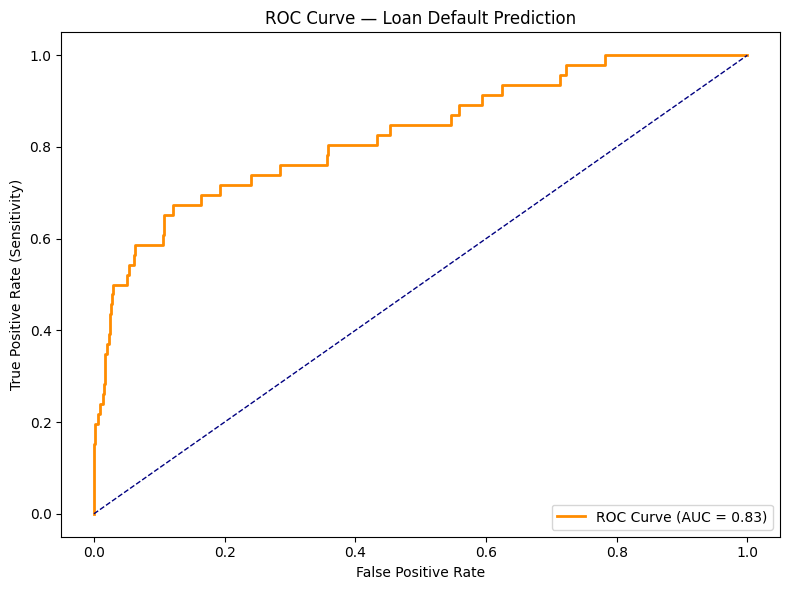

In [16]:
# ROC Curve & AUC

from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities
prob_default = clf_logit.predict_proba(X_test)[:, 1]

# AUC score
auc = roc_auc_score(y_test, prob_default)
print(f"AUC Score: {auc:.4f}")

# Plot ROC curve
fallout, sensitivity, thresholds = roc_curve(y_test, prob_default)

plt.figure(figsize=(8, 6))
plt.plot(fallout, sensitivity, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Loan Default Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

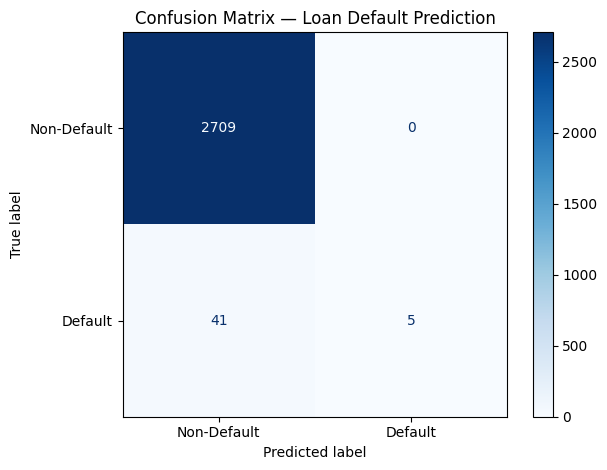

In [17]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Loan Default Prediction')
plt.tight_layout()
plt.show()


In [18]:
# Save the Trained Model

import joblib

# Save the model and feature column names
joblib.dump(clf_logit, 'model.joblib')
joblib.dump(list(X.columns), 'model_features.joblib')

print("Model saved as 'model.joblib'")
print("Features saved as 'model_features.joblib'")

Model saved as 'model.joblib'
Features saved as 'model_features.joblib'


In [19]:
# Streamlit App

app_code = '''
import streamlit as st
import numpy as np
import pandas as pd
import joblib

# Load model and features
model = joblib.load('model.joblib')
model_features = joblib.load('model_features.joblib')

st.set_page_config(page_title="Loan Default Predictor", page_icon="🏦", layout="centered")

st.title("🏦 Loan Default Predictor")
st.markdown("Enter applicant and loan details to assess default risk.")

st.header("👤 Applicant Information")
col1, col2 = st.columns(2)

with col1:
    annual_income = st.number_input("Annual Income ($)", min_value=0.0, max_value=2000000.0, value=60000.0)
    debt_to_income = st.number_input("Debt-to-Income Ratio", min_value=0.0, max_value=100.0, value=15.0)
    homeownership = st.selectbox("Home Ownership", ["RENT", "MORTGAGE", "OWN", "OTHER"])
    verified_income = st.selectbox("Income Verification", ["Not Verified", "Source Verified", "Verified"])
    application_type = st.selectbox("Application Type", ["individual", "joint"])

with col2:
    inquiries_last_12m = st.number_input("Credit Inquiries (Last 12 Months)", min_value=0, max_value=30, value=1)
    open_credit_lines = st.number_input("Open Credit Lines", min_value=0, max_value=50, value=5)
    total_credit_limit = st.number_input("Total Credit Limit ($)", min_value=0.0, value=30000.0)
    total_credit_utilized = st.number_input("Total Credit Utilized ($)", min_value=0.0, value=8000.0)
    num_historical_failed_to_pay = st.number_input("Historical Failed Payments", min_value=0, max_value=50, value=0)

st.header("💳 Loan Details")
col3, col4 = st.columns(2)

with col3:
    loan_amount = st.number_input("Loan Amount ($)", min_value=0.0, max_value=500000.0, value=15000.0)
    interest_rate = st.number_input("Interest Rate (%)", min_value=0.0, max_value=40.0, value=12.0)
    installment = st.number_input("Monthly Installment ($)", min_value=0.0, max_value=5000.0, value=350.0)
    grade = st.selectbox("Loan Grade", ["A", "B", "C", "D", "E", "F", "G"])
    loan_purpose = st.selectbox("Loan Purpose", [
        "car", "credit_card", "debt_consolidation", "educational",
        "home_improvement", "house", "major_purchase", "medical",
        "moving", "other", "renewable_energy", "small_business",
        "vacation", "wedding"
    ])

with col4:
    balance = st.number_input("Current Balance ($)", min_value=0.0, max_value=500000.0, value=10000.0)
    paid_total = st.number_input("Total Paid ($)", min_value=0.0, max_value=500000.0, value=5000.0)
    num_collections_last_12m = st.number_input("Collections Last 12 Months", min_value=0, max_value=20, value=0)
    num_cc_carrying_balance = st.number_input("Credit Cards Carrying Balance", min_value=0, max_value=30, value=2)
    account_never_delinq_percent = st.number_input("% Accounts Never Delinquent", min_value=0.0, max_value=100.0, value=90.0)

# Additional fields (with defaults)
total_credit_lines = st.number_input("Total Credit Lines", min_value=0, max_value=100, value=15)
num_satisfactory_accounts = st.number_input("Satisfactory Accounts", min_value=0, max_value=50, value=10)
num_active_debit_accounts = st.number_input("Active Debit Accounts", min_value=0, max_value=30, value=3)
total_debit_limit = st.number_input("Total Debit Limit ($)", min_value=0.0, value=5000.0)
num_total_cc_accounts = st.number_input("Total Credit Card Accounts", min_value=0, max_value=50, value=5)
num_open_cc_accounts = st.number_input("Open Credit Card Accounts", min_value=0, max_value=30, value=3)
num_mort_accounts = st.number_input("Mortgage Accounts", min_value=0, max_value=20, value=1)
tax_liens = st.number_input("Tax Liens", min_value=0, max_value=10, value=0)
public_record_bankrupt = st.number_input("Bankruptcy Records", min_value=0, max_value=10, value=0)
current_accounts_delinq = st.number_input("Current Accounts Delinquent", min_value=0, max_value=20, value=0)
accounts_opened_24m = st.number_input("Accounts Opened (Last 24 Months)", min_value=0, max_value=30, value=3)

# Encodings
homeownership_map = {"RENT": 0, "MORTGAGE": 1, "OWN": 2, "OTHER": 3}
verified_map = {"Not Verified": 0, "Source Verified": 1, "Verified": 2}
grade_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6}
purpose_list = sorted(["car", "credit_card", "debt_consolidation", "educational",
    "home_improvement", "house", "major_purchase", "medical",
    "moving", "other", "renewable_energy", "small_business", "vacation", "wedding"])
purpose_map = {v: i for i, v in enumerate(purpose_list)}

if st.button("🔍 Predict Default Risk"):
    input_data = pd.DataFrame([[
        annual_income, debt_to_income, inquiries_last_12m,
        total_credit_lines, open_credit_lines, total_credit_limit,
        total_credit_utilized, num_collections_last_12m,
        num_historical_failed_to_pay, current_accounts_delinq,
        accounts_opened_24m, num_satisfactory_accounts,
        num_active_debit_accounts, total_debit_limit,
        num_total_cc_accounts, num_open_cc_accounts,
        num_cc_carrying_balance, num_mort_accounts,
        account_never_delinq_percent, tax_liens,
        public_record_bankrupt, loan_amount, interest_rate,
        installment, balance, paid_total,
        homeownership_map[homeownership],
        verified_map[verified_income],
        purpose_map.get(loan_purpose, 0),
        0 if application_type == "individual" else 1,
        grade_map[grade]
    ]], columns=model_features)

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.markdown("---")
    if prediction == 1:
        st.error(f"⚠️ **HIGH RISK: Likely to Default**")
    else:
        st.success(f"✅ **LOW RISK: Unlikely to Default**")

    st.metric("Default Probability", f"{probability:.1%}")
    st.progress(float(probability))
    st.caption("A probability above 50% indicates higher default risk.")
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py has been created! Run it with: streamlit run app.py")

✅ app.py has been created! Run it with: streamlit run app.py
